# Аналіз ринку квартир — Одеса та Дніпро

**Датасет:** 126 оголошень продажу квартир, бюджет $35 000–$45 000, джерела: OLX, DIM.RIA, REM.ua  
**Мета:** Знайти найвигідніші варіанти для купівлі з подальшою здачею в оренду

---

**Питання аналізу:**
1. Ціна за м² — Одеса vs Дніпро
2. Вплив стану ремонту на ціну
3. Поверховий дисконт
4. Залежність ціни від відстані до центру
5. Рейтинг районів за ціною м²
6. Надбавка за кімнату
7. Свіжість ринку — розподіл дат публікації
8. Порівняння джерел (OLX vs DIM.RIA vs REM.ua)
9. Composite інвестиційний score — топ-10 квартир
10. Варіативність ціни по районах

In [1]:
import warnings
warnings.filterwarnings('ignore')

import csv
from pathlib import Path
from collections import Counter, defaultdict
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

CSV_PATH = Path('../data/apartments_multi_source.csv')
if not CSV_PATH.exists():
    CSV_PATH = Path('../data/sample_apartments.csv')


def parse_float(value, default=None):
    try:
        return float(str(value).replace(',', '.').strip())
    except (ValueError, TypeError):
        return default


def parse_int(value, default=None):
    try:
        return int(str(value).strip())
    except (ValueError, TypeError):
        return default


def parse_date(value):
    for fmt in ('%Y-%m-%d %H:%M:%S', '%Y-%m-%d'):
        try:
            return datetime.strptime(str(value).strip(), fmt)
        except ValueError:
            pass
    return None


with open(CSV_PATH, encoding='utf-8', newline='') as f:
    raw_rows = list(csv.DictReader(f))

rows = []
for r in raw_rows:
    price = parse_int(r['price'])
    area  = parse_float(r['площа'])
    if price is None or area is None or area < 1:
        continue
    rows.append({
        'source':    r['source'].strip(),
        'city':      r['city'].strip(),
        'price':     price,
        'area':      area,
        'price_m2':  round(price / area, 1),
        'rooms':     parse_int(r.get('кількість кімнат', '')),
        'floor':     parse_int(r.get('поверх', '')),
        'floors':    parse_int(r.get('поверховість', '')),
        'district':  r.get('район', '').strip(),
        'km_center': parse_float(r.get('км від центру', '')),
        'repair':    r.get('ремонт', '').strip(),
        'pub_date':  parse_date(r.get('дата публікації', '')),
        'url':       r.get('url', '').strip(),
        'address':   r.get('adress', '').strip(),
    })

cities        = ['Одеса', 'Дніпро']
city_colors   = {'Одеса': '#4C72B0', 'Дніпро': '#DD8452'}
repair_order  = ['євроремонт', 'косметичний ремонт', 'під ремонт', 'радянський ремонт']
repair_colors = {
    'євроремонт':          '#2ca02c',
    'косметичний ремонт':  '#98df8a',
    'під ремонт':          '#ff7f0e',
    'радянський ремонт':   '#d62728',
}
source_colors = {'OLX': '#1f77b4', 'DIM.RIA': '#2ca02c', 'REM.ua': '#9467bd'}

print('Завантажено {} оголошень'.format(len(rows)))
print('Міста:   {}'.format(Counter(r['city'] for r in rows)))
print('Джерела: {}'.format(Counter(r['source'] for r in rows)))
print('Ремонт:  {}'.format(Counter(r['repair'] for r in rows)))

Завантажено 126 оголошень
Міста:   Counter({'Дніпро': 67, 'Одеса': 59})
Джерела: Counter({'OLX': 95, 'DIM.RIA': 23, 'REM.ua': 8})
Ремонт:  Counter({'під ремонт': 53, 'косметичний ремонт': 42, 'євроремонт': 27, 'радянський ремонт': 4})


## 1. Ціна за м² — Одеса vs Дніпро

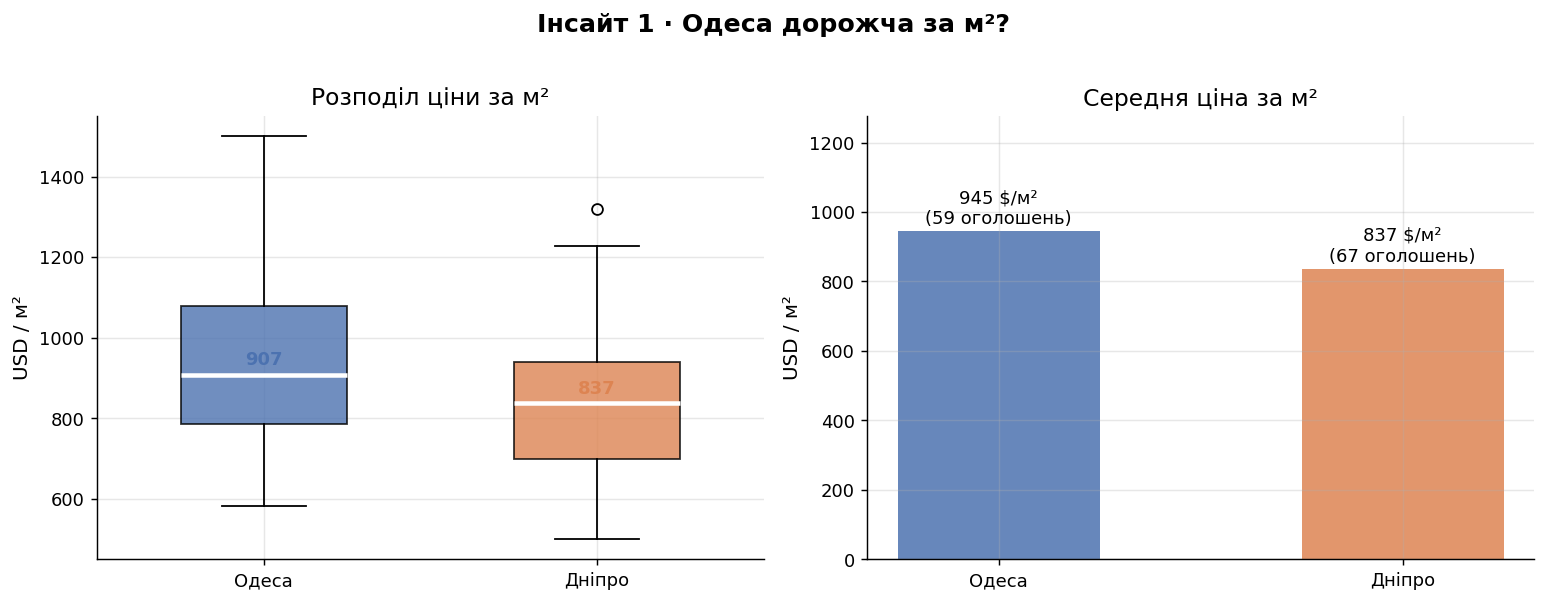

Одеса: median=907  mean=945  std=211  min=583  max=1500  n=59
Дніпро: median=837  mean=837  std=170  min=500  max=1320  n=67


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

data_by_city = [[r['price_m2'] for r in rows if r['city'] == c] for c in cities]

bp = axes[0].boxplot(data_by_city, labels=cities, patch_artist=True, widths=0.5,
                     medianprops=dict(color='white', linewidth=2.5))
for patch, city in zip(bp['boxes'], cities):
    patch.set_facecolor(city_colors[city])
    patch.set_alpha(0.8)
for i, (city, d) in enumerate(zip(cities, data_by_city), 1):
    med = np.median(d)
    axes[0].text(i, med + 15, '{:.0f}'.format(med), ha='center', va='bottom',
                 fontweight='bold', color=city_colors[city])
axes[0].set_title('Розподіл ціни за м²')
axes[0].set_ylabel('USD / м²')

means  = [np.mean(d) for d in data_by_city]
counts = [len(d) for d in data_by_city]
bars = axes[1].bar(cities, means, color=[city_colors[c] for c in cities], alpha=0.85, width=0.5)
for bar, cnt, mean in zip(bars, counts, means):
    axes[1].text(bar.get_x() + bar.get_width() / 2, mean + 10,
                 '{:.0f} $/м²\n({} оголошень)'.format(mean, cnt),
                 ha='center', va='bottom', fontsize=10)
axes[1].set_title('Середня ціна за м²')
axes[1].set_ylabel('USD / м²')
axes[1].set_ylim(0, max(means) * 1.35)

fig.suptitle('Інсайт 1 · Одеса дорожча за м²?', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

for city, d in zip(cities, data_by_city):
    print('{}: median={:.0f}  mean={:.0f}  std={:.0f}  min={:.0f}  max={:.0f}  n={}'.format(
        city, np.median(d), np.mean(d), np.std(d), min(d), max(d), len(d)))

### Висновок · Інсайт 1

**Дніпро дешевший за м² приблизно на 8%:** медіана 837 $/м² проти 907 $/м² в Одесі.

Одеса також більш «розкидана» (std=211 vs 170) — ринок неоднорідніший, ціни більше залежать від локації.

> **Рекомендація:** якщо пріоритет — максимум метражу за бюджет, Дніпро вигідніший. Одеса виправдана, якщо орієнтуватись на туристичну/короткострокову оренду або конкретний район.

## 2. Вплив стану ремонту на ціну за м²

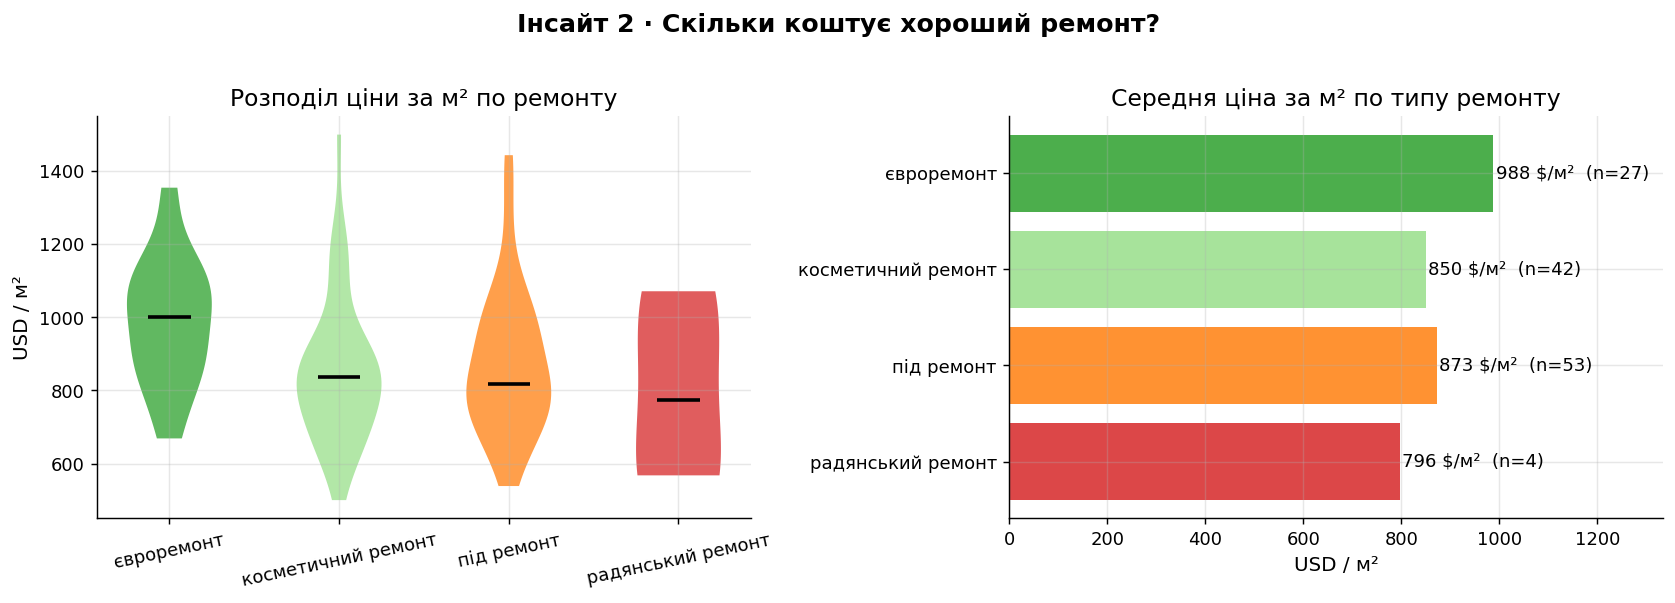

In [3]:
repair_data = {rep: [r['price_m2'] for r in rows if r['repair'] == rep]
               for rep in repair_order}
valid = [r for r in repair_order if repair_data[r]]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

vp = axes[0].violinplot([repair_data[r] for r in valid],
                         positions=range(len(valid)),
                         showmedians=True, showextrema=False)
for body, rep in zip(vp['bodies'], valid):
    body.set_facecolor(repair_colors[rep])
    body.set_alpha(0.75)
vp['cmedians'].set_color('black')
vp['cmedians'].set_linewidth(2)
axes[0].set_xticks(range(len(valid)))
axes[0].set_xticklabels(valid, rotation=12)
axes[0].set_title('Розподіл ціни за м² по ремонту')
axes[0].set_ylabel('USD / м²')

means_r  = [np.mean(repair_data[r]) if repair_data[r] else 0 for r in repair_order]
counts_r = [len(repair_data[r]) for r in repair_order]
bars = axes[1].barh(repair_order, means_r,
                    color=[repair_colors[r] for r in repair_order], alpha=0.85)
for bar, cnt, mean in zip(bars, counts_r, means_r):
    if mean:
        axes[1].text(mean + 5, bar.get_y() + bar.get_height() / 2,
                     '{:.0f} $/м²  (n={})'.format(mean, cnt), va='center', fontsize=10)
axes[1].set_title('Середня ціна за м² по типу ремонту')
axes[1].set_xlabel('USD / м²')
axes[1].invert_yaxis()
axes[1].set_xlim(0, max(means_r) * 1.35)

fig.suptitle('Інсайт 2 · Скільки коштує хороший ремонт?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Висновок · Інсайт 2

**Євроремонт дорожчий за «під ремонт» на ~22%:** 1 000 vs 818 $/м². Різниця для квартири 48 м² — близько $8 800.

«Косметичний ремонт» і «під ремонт» майже однакові за медіаною (837 vs 818 $/м²) — продавці не закладають суттєву надбавку за косметику.

> **Рекомендація:** квартири «під ремонт» — найкраща точка входу: ціна близька до мінімуму, а ремонт можна зробити під орендаря і потім підняти ставку. «Євроремонт» виправданий лише якщо є готовий орендар із вищими вимогами.

## 3. Поверховий дисконт

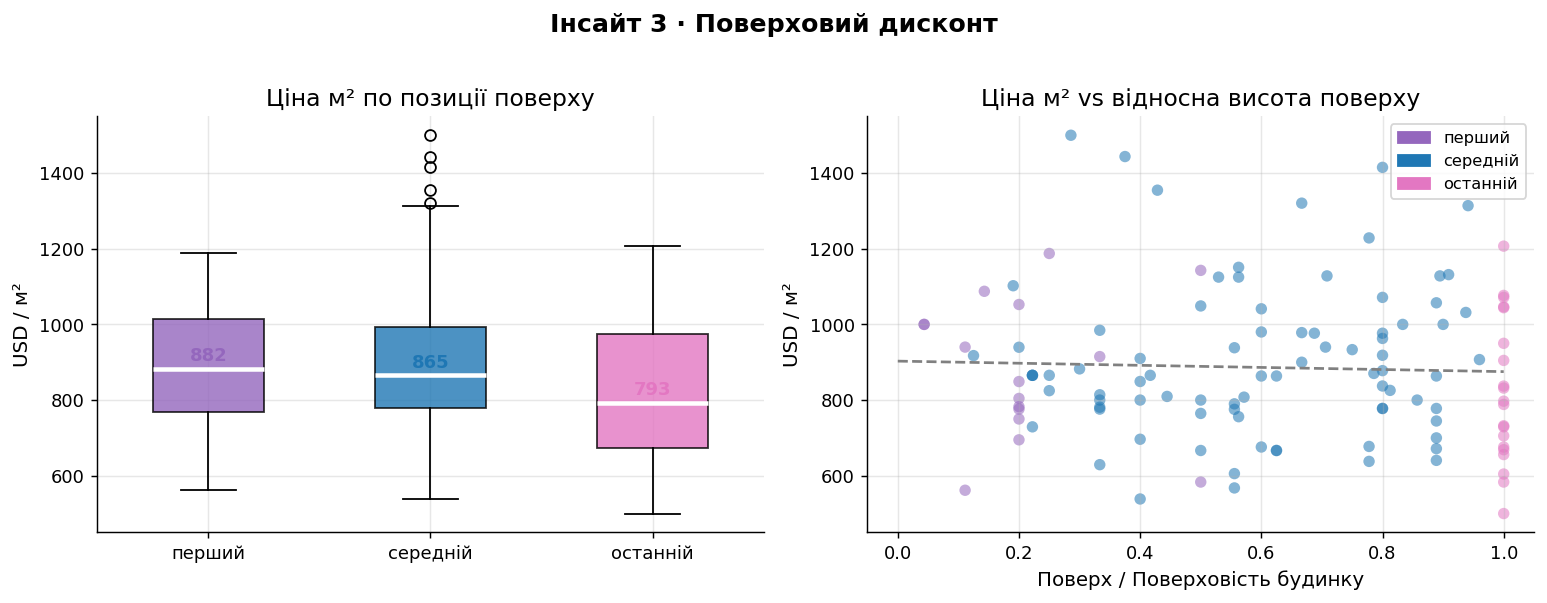

перший        median=882  mean=883  n=16
середній      median=865  mean=902  n=83
останній      median=793  mean=820  n=20


In [4]:
def floor_position(floor, floors):
    if floor is None or floors is None or floors < 2:
        return None
    if floor == 1:
        return 'перший'
    if floor == floors:
        return 'останній'
    return 'середній'


floor_cats   = ['перший', 'середній', 'останній']
floor_colors = {'перший': '#9467bd', 'середній': '#1f77b4', 'останній': '#e377c2'}

floor_data = {cat: [r['price_m2'] for r in rows
                    if floor_position(r['floor'], r['floors']) == cat]
              for cat in floor_cats}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

bp = axes[0].boxplot([floor_data[c] for c in floor_cats], labels=floor_cats,
                      patch_artist=True, widths=0.5,
                      medianprops=dict(color='white', linewidth=2.5))
for patch, cat in zip(bp['boxes'], floor_cats):
    patch.set_facecolor(floor_colors[cat])
    patch.set_alpha(0.8)
for i, cat in enumerate(floor_cats, 1):
    if floor_data[cat]:
        med = np.median(floor_data[cat])
        axes[0].text(i, med + 10, '{:.0f}'.format(med), ha='center', va='bottom',
                     fontweight='bold', color=floor_colors[cat])
axes[0].set_title('Ціна м² по позиції поверху')
axes[0].set_ylabel('USD / м²')

for r in rows:
    cat = floor_position(r['floor'], r['floors'])
    if cat and r['floors'] and r['floors'] > 1:
        ratio = r['floor'] / r['floors']
        axes[1].scatter(ratio, r['price_m2'],
                        color=floor_colors[cat], alpha=0.55, s=40, edgecolors='none')

xy = [(r['floor'] / r['floors'], r['price_m2'])
      for r in rows if r['floor'] and r['floors'] and r['floors'] > 1]
if len(xy) > 2:
    xs, ys = zip(*xy)
    coef = np.polyfit(xs, ys, 1)
    xl   = np.linspace(0, 1, 100)
    axes[1].plot(xl, np.polyval(coef, xl), '--', color='gray',
                 linewidth=1.5, label='тренд: {:+.1f} $/одиниця'.format(coef[0]))

patches = [mpatches.Patch(color=floor_colors[c], label=c) for c in floor_cats]
axes[1].legend(handles=patches, fontsize=9)
axes[1].set_xlabel('Поверх / Поверховість будинку')
axes[1].set_ylabel('USD / м²')
axes[1].set_title('Ціна м² vs відносна висота поверху')

fig.suptitle('Інсайт 3 · Поверховий дисконт', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

for cat in floor_cats:
    d = floor_data[cat]
    if d:
        print('{:12}  median={:.0f}  mean={:.0f}  n={}'.format(
            cat, np.median(d), np.mean(d), len(d)))

### Висновок · Інсайт 3

**Останній поверх дешевший за середній на ~8%:** медіана 793 vs 865 $/м². Перший поверх — аномалія: 882 $/м², вищий за середній.

Кореляція між висотою і ціною слабка — ринок не карає і не преміює поверх системно.

> **Рекомендація:** останній поверх — потенційна знижка ~5–10%, варто перевіряти стан даху. Перший поверх за даними не дешевший — торгуватись є сенс саме на «перший» і «останній».

## 4. Залежність ціни від відстані до центру

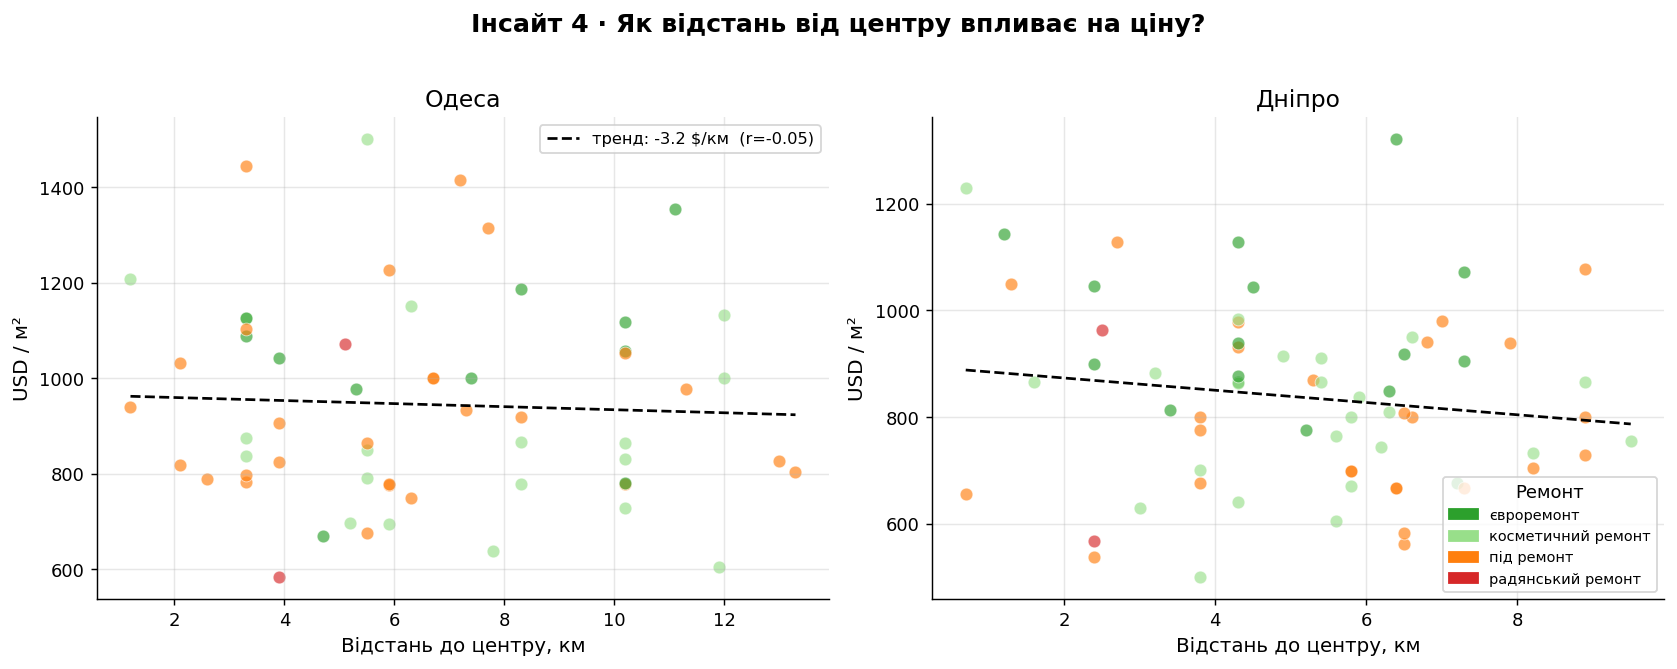

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, city in zip(axes, cities):
    city_rows = [r for r in rows if r['city'] == city and r['km_center'] is not None]
    xs = [r['km_center'] for r in city_rows]
    ys = [r['price_m2']  for r in city_rows]

    for r in city_rows:
        ax.scatter(r['km_center'], r['price_m2'],
                   color=repair_colors.get(r['repair'], 'gray'),
                   alpha=0.65, s=50, edgecolors='white', linewidths=0.5)

    if len(xs) > 3:
        coef = np.polyfit(xs, ys, 1)
        xl   = np.linspace(min(xs), max(xs), 100)
        corr = np.corrcoef(xs, ys)[0, 1]
        ax.plot(xl, np.polyval(coef, xl), '--', color='black',
                linewidth=1.5,
                label='тренд: {:+.1f} $/км  (r={:.2f})'.format(coef[0], corr))
        ax.legend(fontsize=9)

    ax.set_xlabel('Відстань до центру, км')
    ax.set_ylabel('USD / м²')
    ax.set_title(city)

patches = [mpatches.Patch(color=repair_colors[r], label=r) for r in repair_order]
axes[1].legend(handles=patches, title='Ремонт', fontsize=8, loc='lower right')

fig.suptitle('Інсайт 4 · Як відстань від центру впливає на ціну?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Висновок · Інсайт 4

**Залежність слабка в обох містах** (r = −0.05 для Одеси, r = −0.14 для Дніпра). У Дніпрі тренд трохи виразніший: −11.5 $/км, але з великим розкидом.

Це означає, що район і стан ремонту впливають на ціну більше, ніж проста відстань від центру.

> **Рекомендація:** не відкидати квартири на 5–8 км від центру лише через відстань — там реально знайти хорошу ціну/м². У Дніпрі особливо: зона 3–6 км від центру дає баланс ціни та транспортної доступності.

## 5. Рейтинг районів за ціною м²

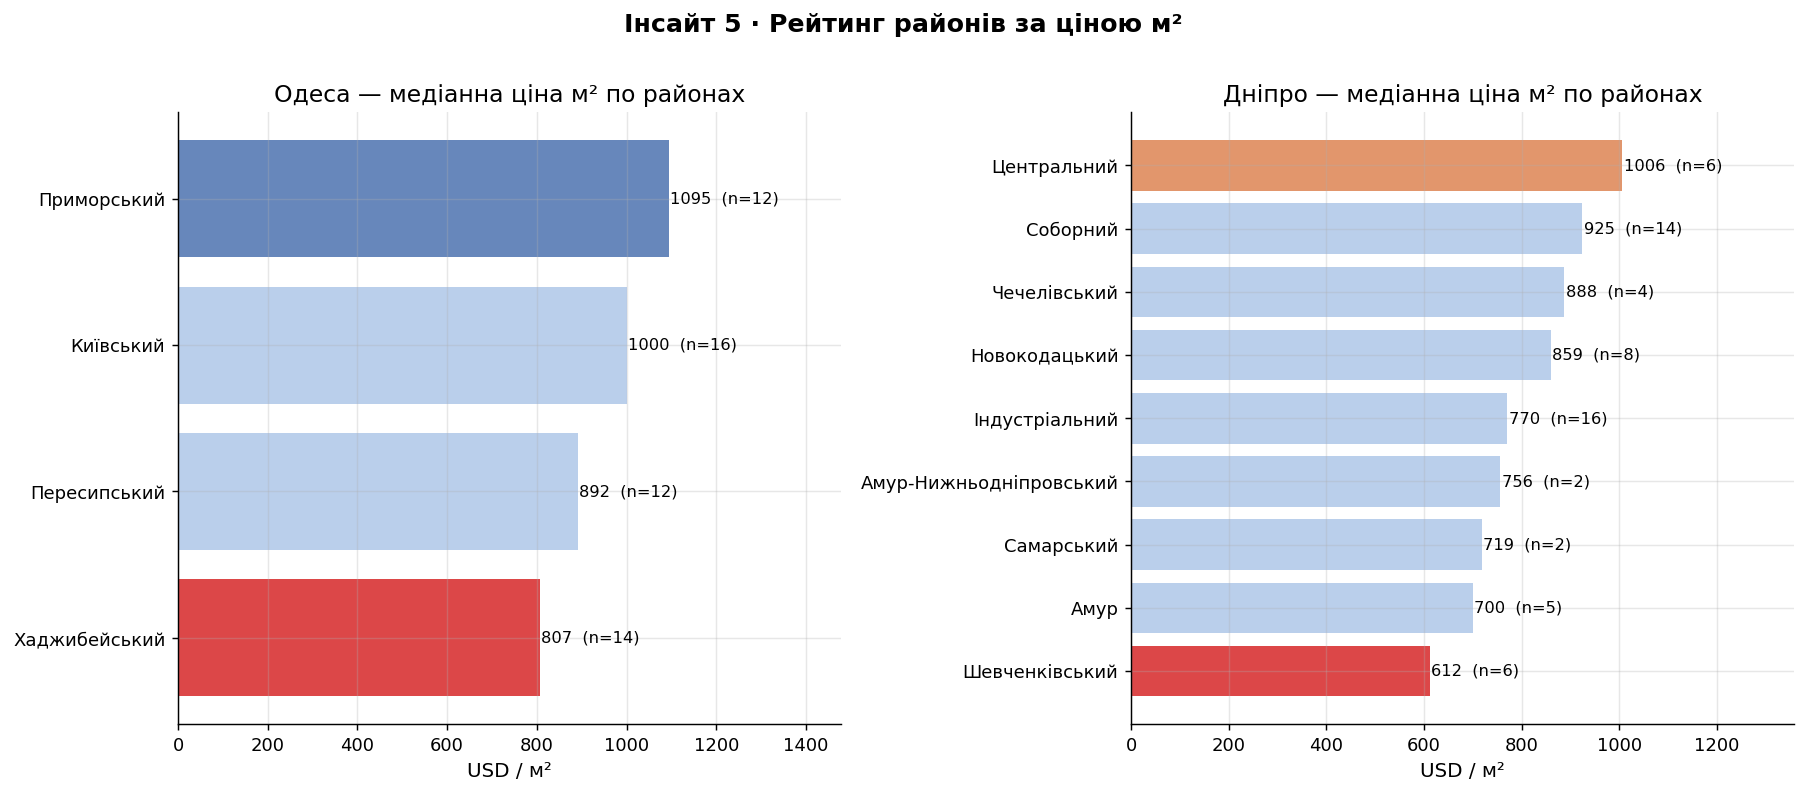

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, city, color in zip(axes, cities, ['#4C72B0', '#DD8452']):
    by_district = defaultdict(list)
    for r in rows:
        if r['city'] == city and r['district']:
            by_district[r['district']].append(r['price_m2'])

    by_district = {d: v for d, v in by_district.items() if len(v) >= 2}
    if not by_district:
        ax.set_title('{} — недостатньо даних'.format(city))
        continue

    sorted_d = sorted(by_district.items(), key=lambda x: np.median(x[1]))
    labels   = [d[:28] + '…' if len(d) > 28 else d for d, _ in sorted_d]
    medians  = [np.median(v) for _, v in sorted_d]
    counts   = [len(v)       for _, v in sorted_d]

    bar_colors = [color if m == max(medians) else
                  ('#d62728' if m == min(medians) else '#aec7e8')
                  for m in medians]
    bars = ax.barh(labels, medians, color=bar_colors, alpha=0.85)

    for bar, cnt, med in zip(bars, counts, medians):
        ax.text(med + 3, bar.get_y() + bar.get_height() / 2,
                '{:.0f}  (n={})'.format(med, cnt), va='center', fontsize=9)

    ax.set_title('{} — медіанна ціна м² по районах'.format(city))
    ax.set_xlabel('USD / м²')
    ax.set_xlim(0, max(medians) * 1.35)

fig.suptitle('Інсайт 5 · Рейтинг районів за ціною м²',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Висновок · Інсайт 5

**Одеса:** найдешевший — Хаджибейський (807 $/м²), найдорожчий — Приморський (1 095 $/м²). Різниця між крайніми районами — 36%.

**Дніпро:** найдешевший — Шевченківський (612 $/м²), найдорожчий — Центральний (1 006 $/м²). Різниця — 64%, розкид більший.

> **Рекомендація:** для оренди найкращий баланс попиту та ціни — **Київський (Одеса)** і **Соборний / Амур (Дніпро)**. Хаджибейський та Шевченківський — найдешевший вхід, але треба перевіряти орендний попит.

## 6. Надбавка за кімнату

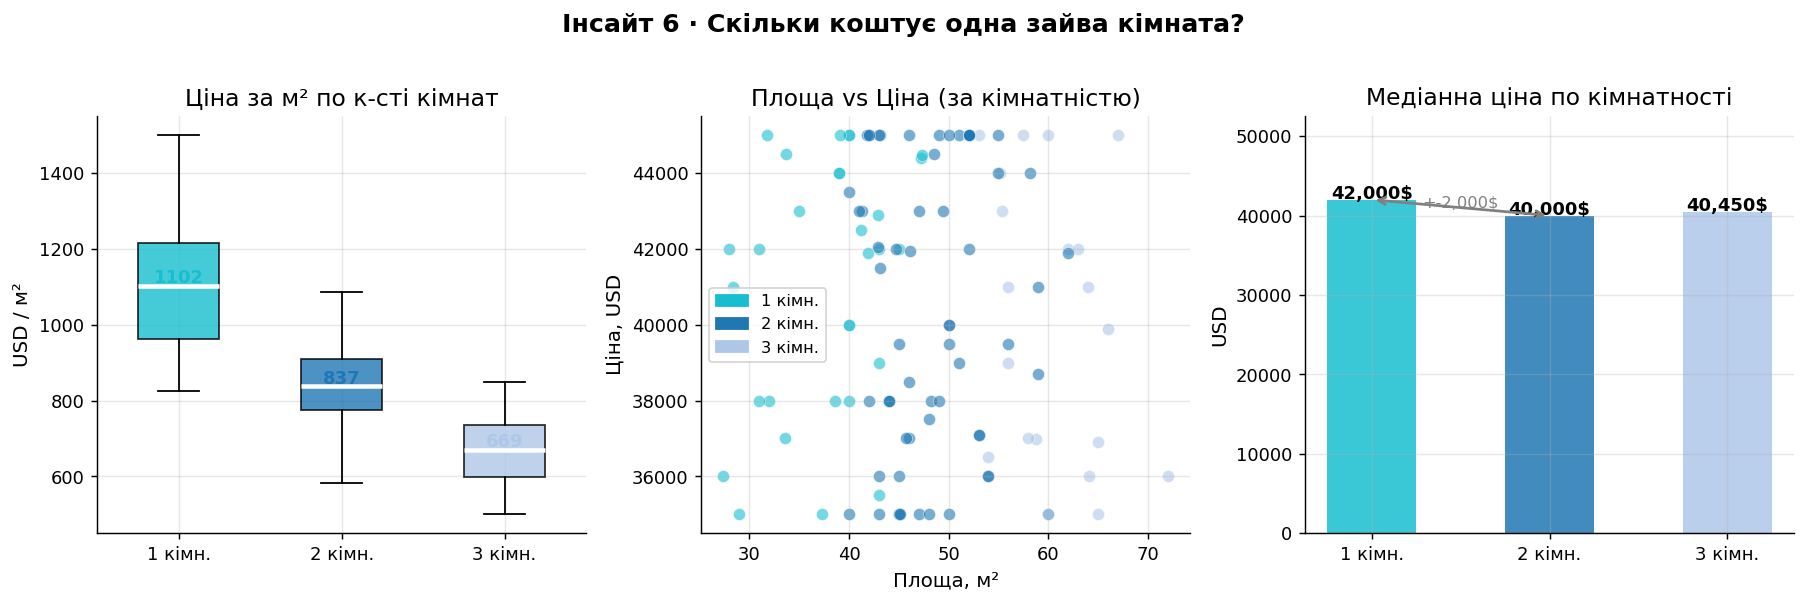

Медіанна ціна:
  1 кімн.: 42,000 USD  (n=31)
  2 кімн.: 40,000 USD  (n=61)
  3 кімн.: 40,450 USD  (n=20)


In [7]:
room_counts = [1, 2, 3]
room_colors = {1: '#17becf', 2: '#1f77b4', 3: '#aec7e8'}
room_pm2 = {n: [r['price_m2'] for r in rows if r['rooms'] == n] for n in room_counts}

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

bp = axes[0].boxplot([room_pm2[n] for n in room_counts],
                      labels=['{} кімн.'.format(n) for n in room_counts],
                      patch_artist=True, widths=0.5,
                      medianprops=dict(color='white', linewidth=2.5))
for patch, n in zip(bp['boxes'], room_counts):
    patch.set_facecolor(room_colors[n])
    patch.set_alpha(0.8)
for i, n in enumerate(room_counts, 1):
    d = room_pm2[n]
    if d:
        axes[0].text(i, np.median(d) + 8, '{:.0f}'.format(np.median(d)),
                     ha='center', fontweight='bold', color=room_colors[n])
axes[0].set_title('Ціна за м² по к-сті кімнат')
axes[0].set_ylabel('USD / м²')

for r in rows:
    if r['rooms'] in room_colors:
        axes[1].scatter(r['area'], r['price'],
                        color=room_colors[r['rooms']], alpha=0.6, s=45,
                        edgecolors='white', linewidths=0.4)
patches_r = [mpatches.Patch(color=room_colors[n], label='{} кімн.'.format(n)) for n in room_counts]
axes[1].legend(handles=patches_r, fontsize=9)
axes[1].set_xlabel('Площа, м²')
axes[1].set_ylabel('Ціна, USD')
axes[1].set_title('Площа vs Ціна (за кімнатністю)')

medians_price = [np.median([r['price'] for r in rows if r['rooms'] == n])
                 for n in room_counts]
bars = axes[2].bar(['{} кімн.'.format(n) for n in room_counts], medians_price,
                   color=[room_colors[n] for n in room_counts], alpha=0.85, width=0.5)
for bar, med in zip(bars, medians_price):
    axes[2].text(bar.get_x() + bar.get_width() / 2, med + 100,
                 '{:,.0f}$'.format(med), ha='center', fontsize=10, fontweight='bold')

if len(medians_price) >= 2:
    delta = medians_price[1] - medians_price[0]
    mid_y = (medians_price[0] + medians_price[1]) / 2
    axes[2].annotate('', xy=(1, medians_price[1]), xytext=(0, medians_price[0]),
                     arrowprops=dict(arrowstyle='<->', color='gray', lw=1.5))
    axes[2].text(0.5, mid_y, '+{:,.0f}$'.format(delta),
                 ha='center', color='gray', fontsize=9)
axes[2].set_title('Медіанна ціна по кімнатності')
axes[2].set_ylabel('USD')
axes[2].set_ylim(0, max(medians_price) * 1.25)

fig.suptitle('Інсайт 6 · Скільки коштує одна зайва кімната?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Медіанна ціна:')
for n, med in zip(room_counts, medians_price):
    print('  {} кімн.: {:,.0f} USD  (n={})'.format(
        n, med, len([r for r in rows if r['rooms'] == n])))

### Висновок · Інсайт 6

**Однокімнатні — найдорожчі за м²:** 1 102 $/м² проти 837 у двокімнатних і 669 у трикімнатних. Але абсолютна ціна майже однакова: 1к = 42 000$, 2к = 40 000$, 3к = 40 450$.

Тобто за ті самі гроші можна взяти 3-кімнатну замість 1-кімнатної.

> **Рекомендація:** **2-кімнатні квартири** — оптимальний вибір для оренди: вищий попит, кращий $/м², і можна здавати одній сім'ї або посімейно. 3-кімнатні цікаві якщо здавати покімнатно — вартість м² там найнижча.

## 7. Свіжість ринку — розподіл дат публікації

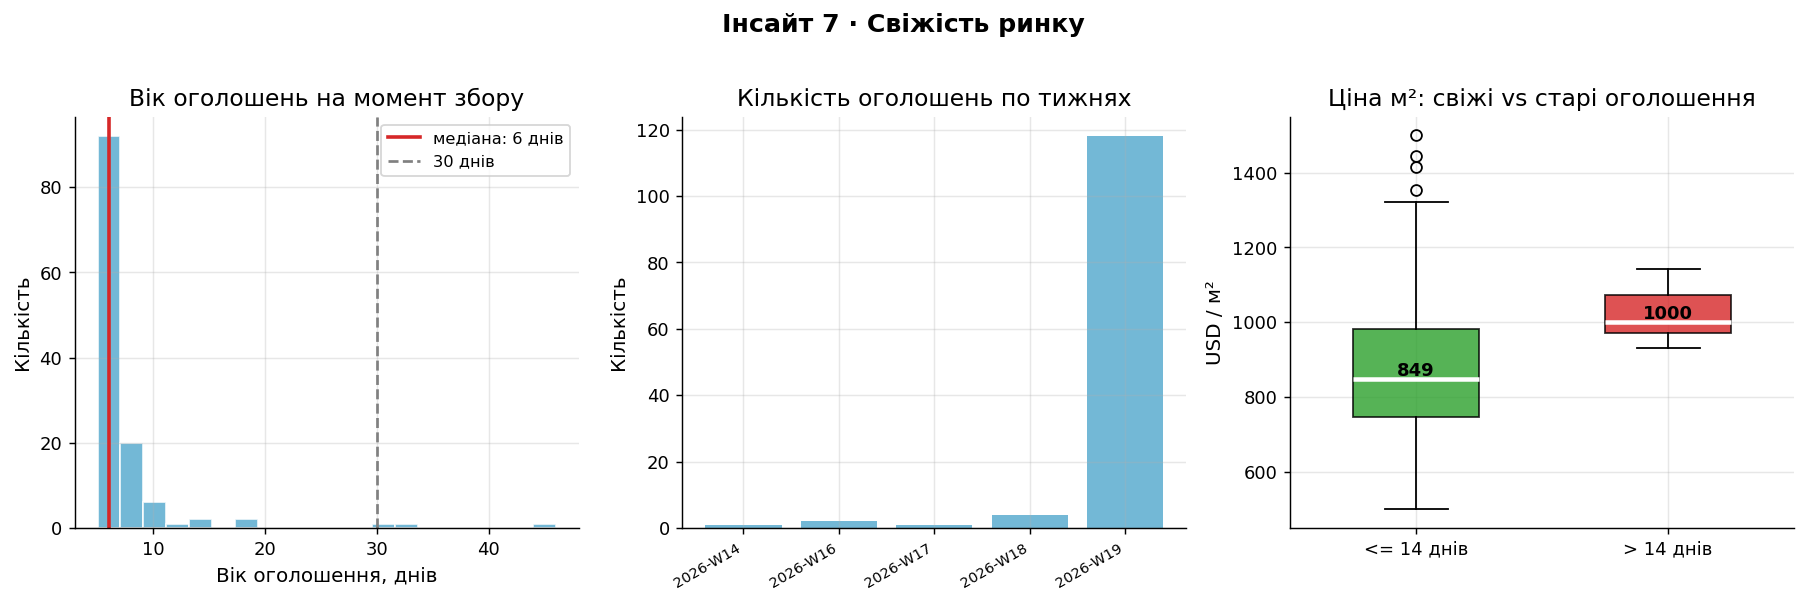

Свіжих (<= 14 днів): 119 (94%)
Старих  (> 14 днів): 7 (5%)
Медіанний вік: 6 днів


In [8]:
now   = datetime.now()
dated = [r for r in rows if r['pub_date']]
ages  = [(now - r['pub_date']).days for r in dated]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

axes[0].hist(ages, bins=20, color='#5aaccf', alpha=0.85, edgecolor='white')
axes[0].axvline(np.median(ages), color='#d62728', linewidth=2,
                label='медіана: {:.0f} днів'.format(np.median(ages)))
axes[0].axvline(30, color='gray', linewidth=1.5, linestyle='--', label='30 днів')
axes[0].set_xlabel('Вік оголошення, днів')
axes[0].set_ylabel('Кількість')
axes[0].set_title('Вік оголошень на момент збору')
axes[0].legend(fontsize=9)

by_week = defaultdict(int)
for r in dated:
    by_week[r['pub_date'].strftime('%Y-W%W')] += 1
sorted_weeks = sorted(by_week.items())
if sorted_weeks:
    wlabels, wcounts = zip(*sorted_weeks)
    axes[1].bar(range(len(wlabels)), wcounts, color='#5aaccf', alpha=0.85)
    step = max(1, len(wlabels) // 8)
    axes[1].set_xticks(range(0, len(wlabels), step))
    axes[1].set_xticklabels([wlabels[i] for i in range(0, len(wlabels), step)],
                             rotation=30, ha='right', fontsize=8)
axes[1].set_title('Кількість оголошень по тижнях')
axes[1].set_ylabel('Кількість')

fresh_pm2 = [r['price_m2'] for r, age in zip(dated, ages) if age <= 14]
old_pm2   = [r['price_m2'] for r, age in zip(dated, ages) if age >  14]
bp = axes[2].boxplot([fresh_pm2, old_pm2], labels=['<= 14 днів', '> 14 днів'],
                     patch_artist=True, widths=0.5,
                     medianprops=dict(color='white', linewidth=2.5))
for patch, color in zip(bp['boxes'], ['#2ca02c', '#d62728']):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
for i, d in enumerate([fresh_pm2, old_pm2], 1):
    if d:
        axes[2].text(i, np.median(d) + 8, '{:.0f}'.format(np.median(d)),
                     ha='center', fontweight='bold')
axes[2].set_title('Ціна м²: свіжі vs старі оголошення')
axes[2].set_ylabel('USD / м²')

fig.suptitle('Інсайт 7 · Свіжість ринку', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

fresh_n = sum(1 for a in ages if a <= 14)
old_n   = sum(1 for a in ages if a > 14)
print('Свіжих (<= 14 днів): {} ({}%)'.format(fresh_n, 100 * fresh_n // len(ages)))
print('Старих  (> 14 днів): {} ({}%)'.format(old_n,   100 * old_n   // len(ages)))
print('Медіанний вік: {:.0f} днів'.format(np.median(ages)))

### Висновок · Інсайт 7

**Ринок дуже свіжий:** 94% оголошень молодші 14 днів, медіанний вік — 6 днів. Затяжних «зависань» майже немає.

Цікавий сигнал: старі оголошення (>14 днів) мають медіану 1 000 $/м² — на 18% вищу за свіжі (849 $/м²). Ймовірно, це переоцінені лоти, які не продаються.

> **Рекомендація:** якщо оголошення зависло більш ніж на 2 тижні — це сигнал або про завищену ціну, або про приховані проблеми. Свіжі оголошення (≤7 днів) — пріоритет для перегляду.

## 8. Порівняння джерел: OLX vs DIM.RIA vs REM.ua

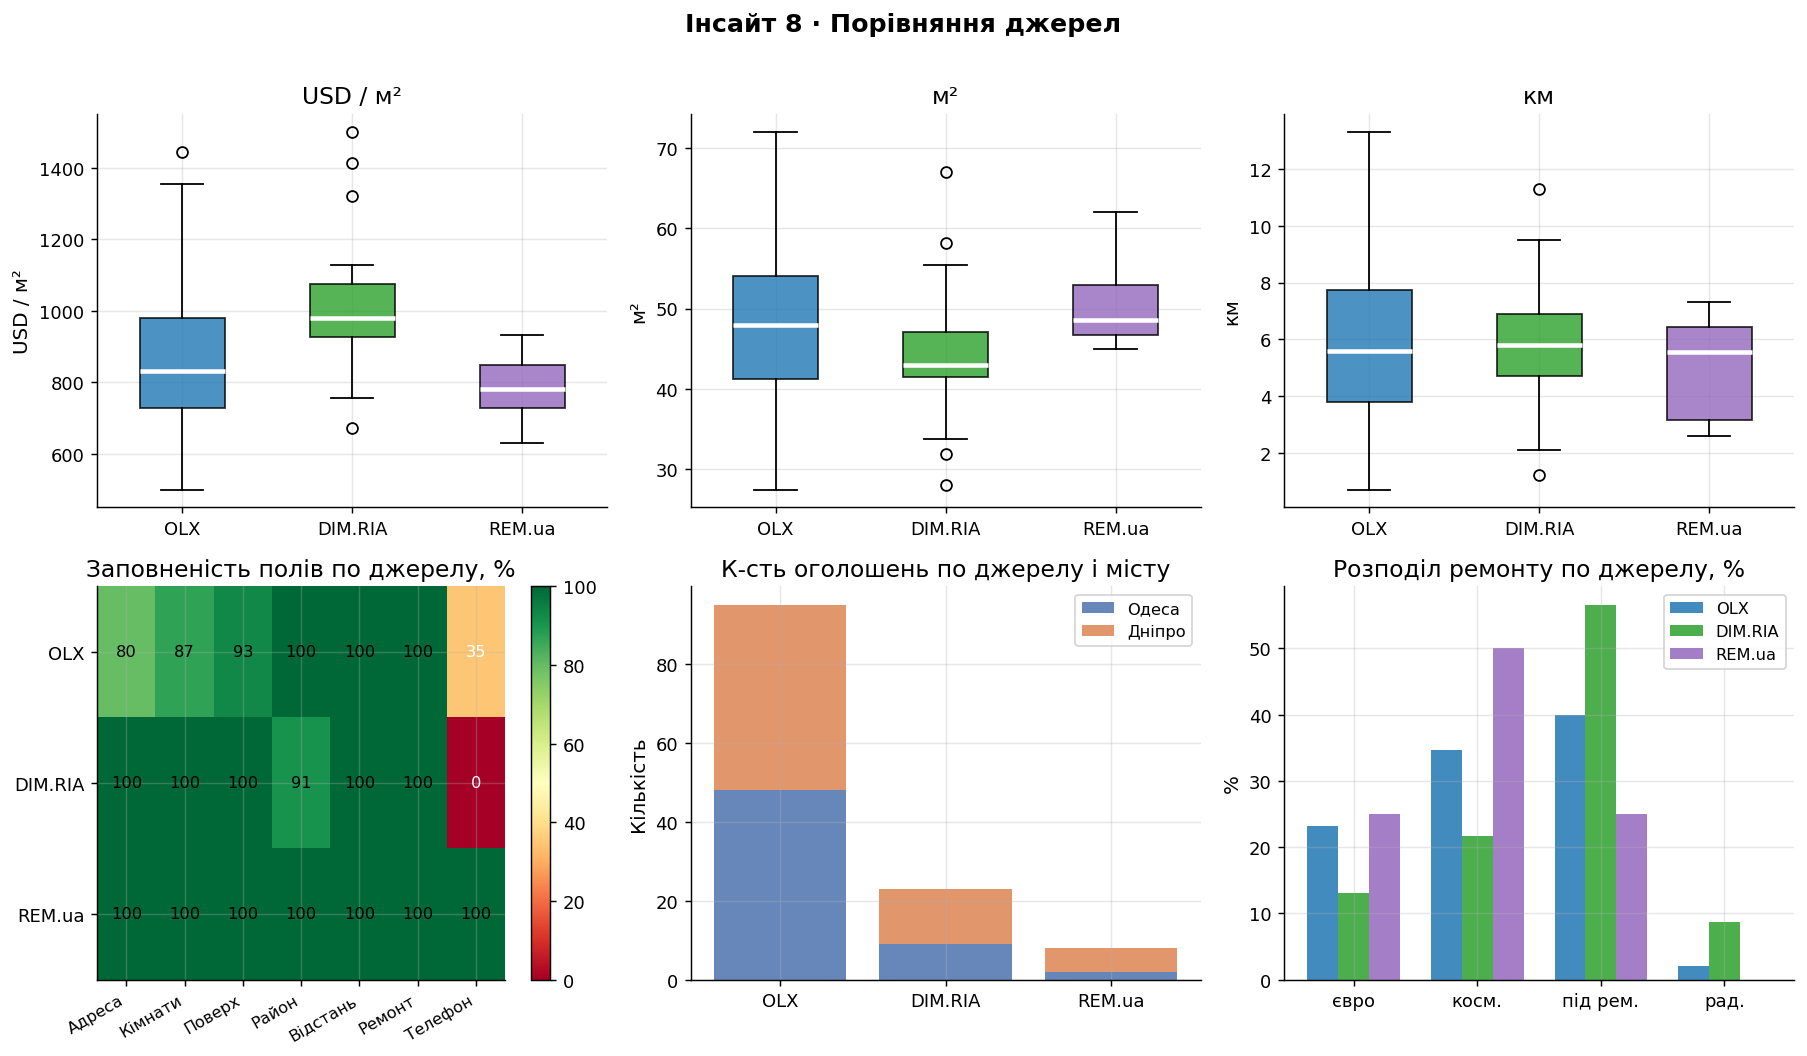

In [9]:
sources_order = ['OLX', 'DIM.RIA', 'REM.ua']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for col, (field, ylabel) in enumerate([('price_m2', 'USD / м²'),
                                        ('area',     'м²'),
                                        ('km_center','км')]):
    data = {src: [r[field] for r in rows if r['source'] == src and r[field] is not None]
            for src in sources_order}
    bp = axes[0, col].boxplot([data[s] for s in sources_order],
                               labels=sources_order, patch_artist=True, widths=0.5,
                               medianprops=dict(color='white', linewidth=2.5))
    for patch, src in zip(bp['boxes'], sources_order):
        patch.set_facecolor(source_colors[src])
        patch.set_alpha(0.8)
    axes[0, col].set_title(ylabel)
    axes[0, col].set_ylabel(ylabel)

completeness_fields = ['adress', 'кількість кімнат', 'поверх', 'район',
                        'км від центру', 'ремонт', 'телефон']
field_labels        = ['Адреса', 'Кімнати', 'Поверх', 'Район',
                        'Відстань', 'Ремонт', 'Телефон']
matrix = []
for src in sources_order:
    src_r = [r for r in raw_rows if r.get('source', '').strip() == src]
    matrix.append([round(100 * sum(1 for r in src_r if r.get(f, '').strip()) / len(src_r))
                   if src_r else 0 for f in completeness_fields])

im = axes[1, 0].imshow(matrix, aspect='auto', cmap='RdYlGn', vmin=0, vmax=100)
axes[1, 0].set_xticks(range(len(completeness_fields)))
axes[1, 0].set_xticklabels(field_labels, rotation=30, ha='right', fontsize=9)
axes[1, 0].set_yticks(range(len(sources_order)))
axes[1, 0].set_yticklabels(sources_order)
axes[1, 0].set_title('Заповненість полів по джерелу, %')
for i, row_vals in enumerate(matrix):
    for j, val in enumerate(row_vals):
        axes[1, 0].text(j, i, str(val), ha='center', va='center', fontsize=9,
                        color='black' if val > 50 else 'white')
plt.colorbar(im, ax=axes[1, 0])

city_source = defaultdict(Counter)
for r in rows:
    city_source[r['source']][r['city']] += 1

bottom = [0] * len(sources_order)
for city_name, clr in city_colors.items():
    heights = [city_source[src][city_name] for src in sources_order]
    axes[1, 1].bar(sources_order, heights, bottom=bottom, label=city_name, color=clr, alpha=0.85)
    bottom = [b + h for b, h in zip(bottom, heights)]
axes[1, 1].legend(fontsize=9)
axes[1, 1].set_title('К-сть оголошень по джерелу і місту')
axes[1, 1].set_ylabel('Кількість')

repair_short = ['євро', 'косм.', 'під рем.', 'рад.']
x = np.arange(len(repair_order))
w = 0.25
for idx, src in enumerate(sources_order):
    src_rows_list = [r for r in rows if r['source'] == src]
    total = len(src_rows_list) or 1
    fracs = [100 * sum(1 for r in src_rows_list if r['repair'] == rep) / total
             for rep in repair_order]
    axes[1, 2].bar(x + idx * w, fracs, width=w,
                   label=src, color=source_colors[src], alpha=0.85)
axes[1, 2].set_xticks(x + w)
axes[1, 2].set_xticklabels(repair_short)
axes[1, 2].set_title('Розподіл ремонту по джерелу, %')
axes[1, 2].set_ylabel('%')
axes[1, 2].legend(fontsize=9)

fig.suptitle('Інсайт 8 · Порівняння джерел', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Висновок · Інсайт 8

**REM.ua** — найдешевший медіанний $/м² (782), 100% заповненість телефонів. Але лише 8 оголошень — мала вибірка.

**OLX** — найбільше оголошень (95, 75% датасету), медіана 832 $/м², але телефони лише у 34% — потрібне браузерне збагачення.

**DIM.RIA** — найдорожчий медіанний $/м² (980), але найкраща якість даних: адреса, поверх, район заповнені у 100%.

> **Рекомендація:** використовувати всі три джерела разом. **DIM.RIA** — для якісної структурованої інформації, **OLX** — для широти покриття і пошуку дешевих варіантів, **REM.ua** — для прямого контакту (телефон одразу є).

## 9. Composite інвестиційний score — топ-10 квартир

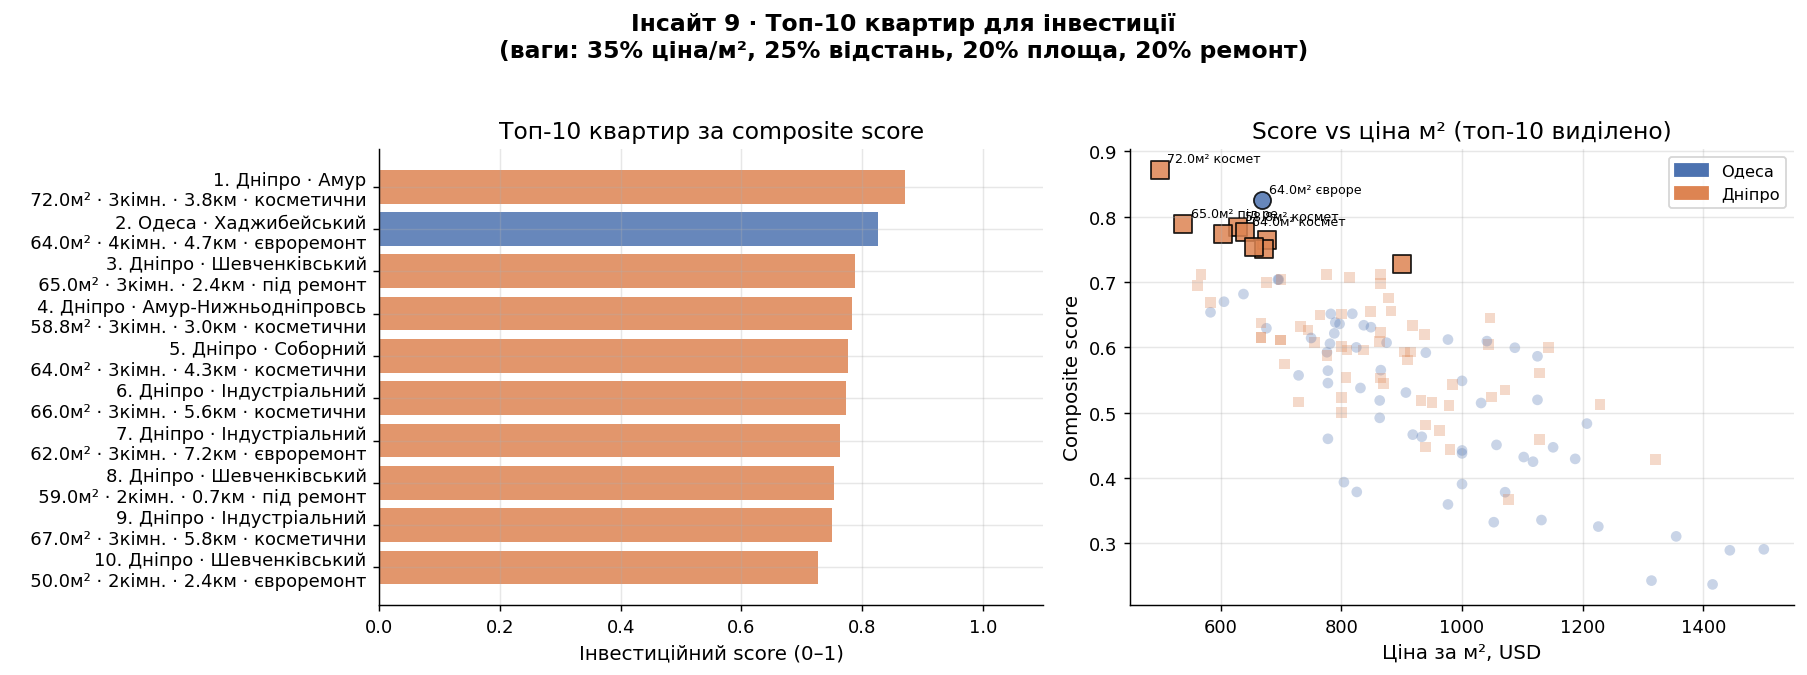

 #  Місто   Район                             $    м2  к     пов     км  ремонт              score
----------------------------------------------------------------------------------------------------
 1  Дніпро  Амур                          36000  72.0  3   10/10    3.8  косметичний ремонт  0.872
 2  Одеса   Хаджибейський                 42800  64.0  4     5/5    4.7  євроремонт          0.826
 3  Дніпро  Шевченківський                35000  65.0  3    4/10    2.4  під ремонт          0.788
 4  Дніпро  Амур-Нижньодніпровський       36996  58.8  3     3/9    3.0  косметичний ремонт  0.783
 5  Дніпро  Соборний                      41000  64.0  3     8/9    4.3  косметичний ремонт  0.777
 6  Дніпро  Індустріальний                39900  66.0  3     2/2    5.6  косметичний ремонт  0.773
 7  Дніпро  Індустріальний                42000  62.0  3     7/9    7.2  євроремонт          0.764
 8  Дніпро  Шевченківський                38700  59.0  2     2/2    0.7  під ремонт          0.754
 9  Дніп

In [10]:
repair_score_map = {
    'євроремонт':          4,
    'косметичний ремонт':  3,
    'під ремонт':          2,
    'радянський ремонт':   1,
    '':                    1,
}


def minmax_norm(values, inverse=False):
    mn, mx = min(values), max(values)
    if mx == mn:
        return [0.5] * len(values)
    norm = [(v - mn) / (mx - mn) for v in values]
    return [1 - n for n in norm] if inverse else norm


scored = [r for r in rows if r['km_center'] is not None]

pm2_norm    = minmax_norm([r['price_m2']                        for r in scored], inverse=True)
area_norm   = minmax_norm([r['area']                            for r in scored])
km_norm     = minmax_norm([r['km_center']                       for r in scored], inverse=True)
repair_norm = minmax_norm([repair_score_map.get(r['repair'], 1) for r in scored])

W = {'price_m2': 0.35, 'area': 0.20, 'km': 0.25, 'repair': 0.20}

for i, r in enumerate(scored):
    r['score'] = round(
        W['price_m2'] * pm2_norm[i] +
        W['area']     * area_norm[i] +
        W['km']       * km_norm[i] +
        W['repair']   * repair_norm[i],
        4
    )

top10 = sorted(scored, key=lambda r: r['score'], reverse=True)[:10]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels_top = [
    '{}. {} · {}\n   {}м² · {}кімн. · {}км · {}'.format(
        i + 1, r['city'],
        (r['district'] or '?')[:20],
        r['area'], r['rooms'] or '?',
        r['km_center'], r['repair'][:10]
    )
    for i, r in enumerate(top10)
]
score_colors_list = [city_colors.get(r['city'], '#888') for r in top10]

axes[0].barh(labels_top[::-1], [r['score'] for r in top10[::-1]],
             color=score_colors_list[::-1], alpha=0.85)
axes[0].set_xlabel('Інвестиційний score (0–1)')
axes[0].set_title('Топ-10 квартир за composite score')
axes[0].set_xlim(0, 1.1)

city_marker = {'Одеса': 'o', 'Дніпро': 's'}
for r in scored:
    is_top = r in top10
    axes[1].scatter(r['price_m2'], r['score'],
                    color=city_colors.get(r['city'], 'gray'),
                    marker=city_marker.get(r['city'], 'o'),
                    alpha=0.85 if is_top else 0.3,
                    s=90 if is_top else 35,
                    edgecolors='black' if is_top else 'none',
                    linewidths=1.0)
for r in top10[:5]:
    axes[1].annotate('{}м² {}'.format(r['area'], r['repair'][:6]),
                     (r['price_m2'], r['score']),
                     xytext=(4, 4), textcoords='offset points', fontsize=7)

patches_c = [mpatches.Patch(color=city_colors[c], label=c) for c in cities]
axes[1].legend(handles=patches_c, fontsize=9)
axes[1].set_xlabel('Ціна за м², USD')
axes[1].set_ylabel('Composite score')
axes[1].set_title('Score vs ціна м² (топ-10 виділено)')

fig.suptitle(
    'Інсайт 9 · Топ-10 квартир для інвестиції\n'
    '(ваги: {:.0f}% ціна/м², {:.0f}% відстань, {:.0f}% площа, {:.0f}% ремонт)'.format(
        W['price_m2'] * 100, W['km'] * 100, W['area'] * 100, W['repair'] * 100),
    fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print('{:>2}  {:7} {:28} {:>6} {:>5} {:>2} {:>7}  {:>5}  {:18}  score'.format(
    '#', 'Місто', 'Район', '$', 'м2', 'к', 'пов', 'км', 'ремонт'))
print('-' * 100)
for i, r in enumerate(top10, 1):
    floor_str = '{}/{}'.format(r['floor'], r['floors']) if r['floor'] else '?'
    print('{:>2}  {:7} {:28} {:>6} {:>5} {:>2} {:>7}  {:>5}  {:18}  {:.3f}'.format(
        i, r['city'], (r['district'] or '?')[:28],
        r['price'], r['area'], str(r['rooms'] or '?'),
        floor_str, str(r['km_center'] or '?'),
        r['repair'][:18], r['score']))

### Висновок · Інсайт 9

**Топ-1:** Дніпро, Амур — 72 м², 36 000$, 3.8 км від центру, косметичний ремонт. Score: 0.872  
**Топ-2:** Одеса, Хаджибейський — 64 м², 42 800$, 4.7 км, євроремонт. Score: 0.826  
**Топ-3:** Дніпро, Шевченківський — 65 м², 35 000$, 2.4 км, під ремонт. Score: 0.788

Дніпро домінує в топ-10 — через нижчу ціну/м² при прийнятних відстанях.

> **Рекомендація:** composite score — стартова точка, не фінальне рішення. Перед дзвінком перевіряти: стан будинку, рік побудови, інфраструктуру поруч, наявність ОСББ, юридичну чистоту. Ваги score легко налаштувати під особисті пріоритети.

## 10. Варіативність ціни по районах

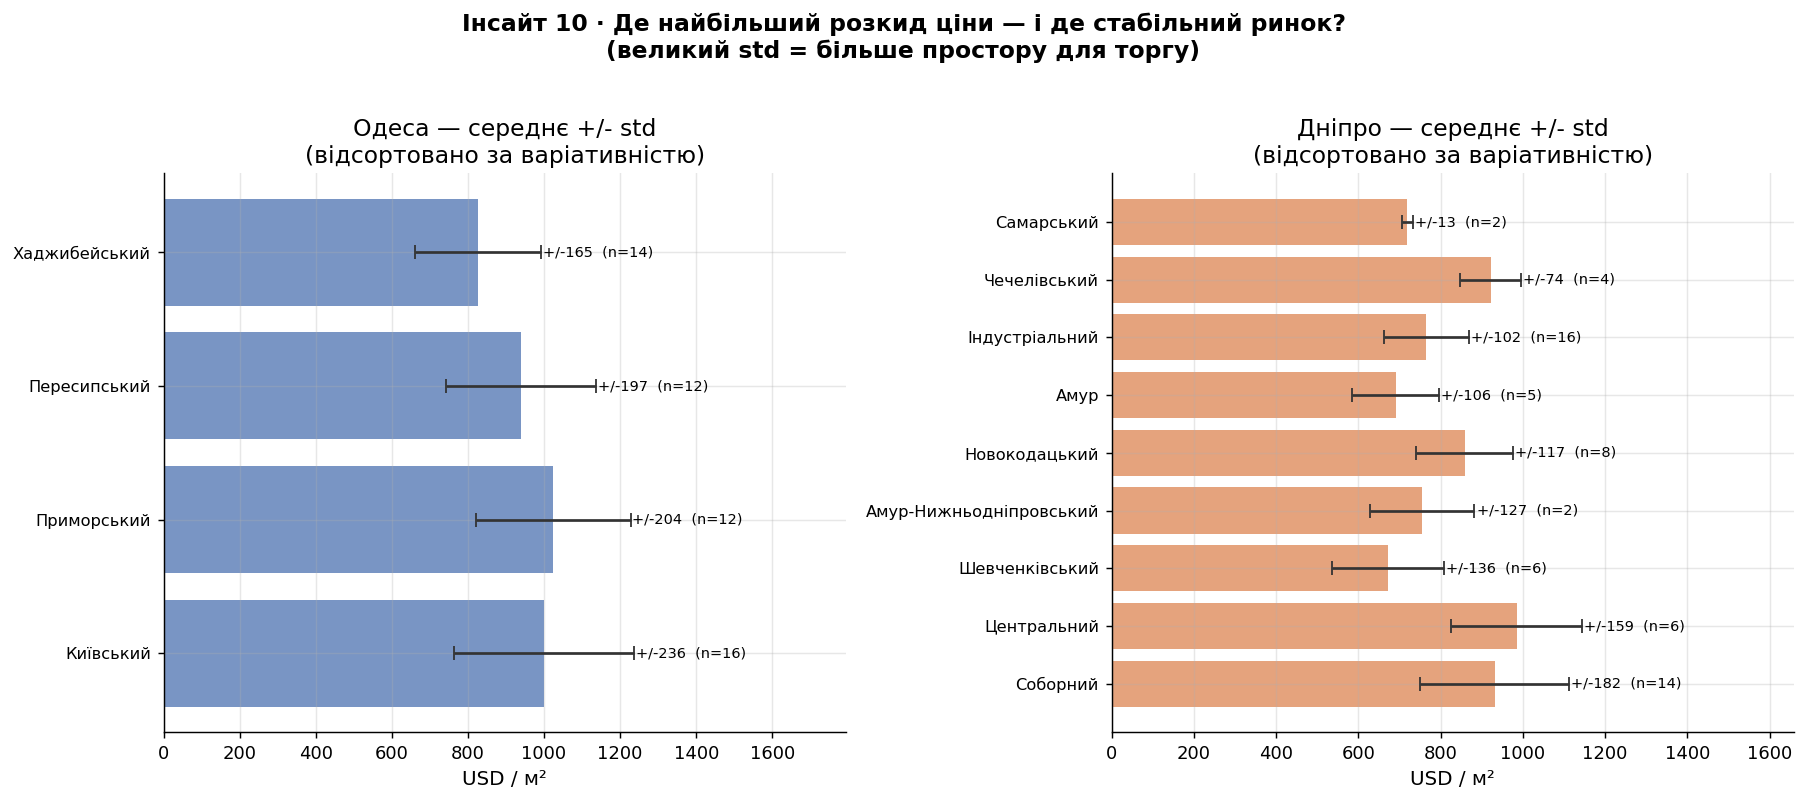

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, city, color in zip(axes, cities, ['#4C72B0', '#DD8452']):
    by_district = defaultdict(list)
    for r in rows:
        if r['city'] == city and r['district']:
            by_district[r['district']].append(r['price_m2'])

    by_district = {d: v for d, v in by_district.items() if len(v) >= 2}
    if not by_district:
        continue

    sorted_d = sorted(by_district.items(), key=lambda x: np.std(x[1]), reverse=True)
    labels  = [d[:28] + '…' if len(d) > 28 else d for d, _ in sorted_d]
    means   = [np.mean(v) for _, v in sorted_d]
    stds    = [np.std(v)  for _, v in sorted_d]
    counts  = [len(v)     for _, v in sorted_d]

    y_pos = range(len(labels))
    ax.barh(y_pos, means, xerr=stds, color=color, alpha=0.75,
            error_kw=dict(ecolor='#333', capsize=4, lw=1.5))
    for y, mean, std, cnt in zip(y_pos, means, stds, counts):
        ax.text(mean + std + 5, y,
                '+/-{:.0f}  (n={})'.format(std, cnt), va='center', fontsize=8)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel('USD / м²')
    ax.set_title('{} — середнє +/- std\n(відсортовано за варіативністю)'.format(city))
    ax.set_xlim(0, max(m + s for m, s in zip(means, stds)) * 1.45)

fig.suptitle(
    'Інсайт 10 · Де найбільший розкид ціни — і де стабільний ринок?\n'
    '(великий std = більше простору для торгу)',
    fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Висновок · Інсайт 10

**Одеса:** найбільший розкид — Київський (±236 $/м²) і Приморський (±204). Тут є як дуже дешеві, так і дорогі варіанти — найбільший простір для торгу.

**Дніпро:** Самарський (±13 $/м²) і Чечелівський (±74) — ціни стабільні, торг там малоймовірний. Соборний (±182) — найбільший розкид, є потенціал.

> **Рекомендація:** у районах з великим std (Київський Одеса, Соборний Дніпро) треба дивитися на конкретний будинок — там є і погані, і відмінні варіанти. У стабільних районах (Самарський, Чечелівський) ціна передбачувана — торг зазвичай незначний.

## Зведений дашборд — ключові числа

In [12]:
print('=' * 62)
print('  SUMMARY — Ринок квартир Одеса + Дніпро ($35k–$45k)')
print('=' * 62)
print('  Всього оголошень:    {}'.format(len(rows)))
print('  Медіанна ціна:       {:,.0f} USD'.format(np.median([r['price'] for r in rows])))
print('  Медіанна ціна/м²:    {:,.0f} USD/м²'.format(np.median([r['price_m2'] for r in rows])))
print('  Медіанна площа:      {:.0f} м²'.format(np.median([r['area'] for r in rows])))
print('  Медіанна відстань:   {:.1f} км від центру'.format(
    np.median([r['km_center'] for r in rows if r['km_center']])))
print()
for city in cities:
    cr = [r for r in rows if r['city'] == city]
    print('  {} ({} оголошень):'.format(city, len(cr)))
    print('    Медіанна ціна/м²: {:,.0f} USD/м²'.format(np.median([r['price_m2'] for r in cr])))
    print('    Медіанна площа:   {:.0f} м²'.format(np.median([r['area'] for r in cr])))
print()
print('  Розподіл по ремонту:')
for rep, cnt in Counter(r['repair'] for r in rows).most_common():
    print('    {:22} {:3}  ({}%)'.format(rep, cnt, 100 * cnt // len(rows)))
print('=' * 62)

  SUMMARY — Ринок квартир Одеса + Дніпро ($35k–$45k)
  Всього оголошень:    126
  Медіанна ціна:       41,000 USD
  Медіанна ціна/м²:    864 USD/м²
  Медіанна площа:      46 м²
  Медіанна відстань:   5.7 км від центру

  Одеса (59 оголошень):
    Медіанна ціна/м²: 907 USD/м²
    Медіанна площа:   43 м²
  Дніпро (67 оголошень):
    Медіанна ціна/м²: 837 USD/м²
    Медіанна площа:   49 м²

  Розподіл по ремонту:
    під ремонт              53  (42%)
    косметичний ремонт      42  (33%)
    євроремонт              27  (21%)
    радянський ремонт        4  (3%)
